In [1]:
import numpy as np
import torch
import argparse
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms
from PIL import Image
from animal_classifier import AnimalImageClassifier
from caltech_classifier import CaltechImageClassifier
from brain_tumor_classifier import BrainTumorClassifier
from sample_prediction import explain_with_lime, explain_with_pebex, explain_with_shap, renormalize_image
from utils import load_sample_from_animals, load_sample_from_brain_tumor, load_sample_from_caltech, predict_with_model

In [2]:
data_dir = 'data'
output_dir = 'outputs'
sample_output_dir = 'outputs/sample_explanation'
img_size = 224

In [3]:
import os

# Lấy thư mục hiện tại
current_dir = os.getcwd()
print("📁 Thư mục hiện tại:", current_dir)

# Lùi về 1 cấp
parent_dir = os.path.dirname(current_dir)

# Cập nhật (chuyển) thư mục làm việc sang thư mục cha
os.chdir(parent_dir)
print("⬆️  Đã lùi về:", os.getcwd())


📁 Thư mục hiện tại: e:\KLTN\src\XAI\codes\src
⬆️  Đã lùi về: e:\KLTN\src\XAI\codes


## Animal Image Dataset

True


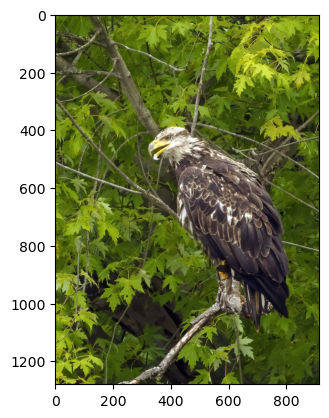

In [4]:
img_path = os.path.join(parent_dir, 'data/animals/eagle/07c29966bd.jpg')
import os
print(os.path.exists(img_path))
animal_img = cv2.imread(img_path)
img = cv2.cvtColor(animal_img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Giải thích với mô hình Efficientnet-B3

In [5]:
clf = AnimalImageClassifier(data_dir=data_dir, output_dir=output_dir, img_size=img_size, args_model='efficientnet_b3')

clf._build_dataloaders()
clf.load_trained_model()

# Dự đoán với mô hình
print("\n🔮 Dự đoán với mô hình...")

org_image = Image.open(img_path).convert('RGB').resize((img_size, img_size))
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_tensor = transform(org_image).unsqueeze(0)
img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

pred_class, confidence, probs = predict_with_model(clf.model, img_tensor)

# Xác định index lớp đúng dựa trên tên class được chọn
print(f"   - Predicted class: {clf.class_names[pred_class]} (index: {pred_class})")
print(f"   - Confidence: {confidence:.4f}")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



🔮 Dự đoán với mô hình...
   - Predicted class: eagle (index: 23)
   - Confidence: 0.9878


   - Tạo thư mục: outputs\sample_explanation\caltech-101\lime
🔍 Đang chạy LIME...
   - Input shape: (224, 224, 3)
   - Output dir: outputs/sample_explanation/caltech-101


  0%|          | 0/2000 [00:00<?, ?it/s]

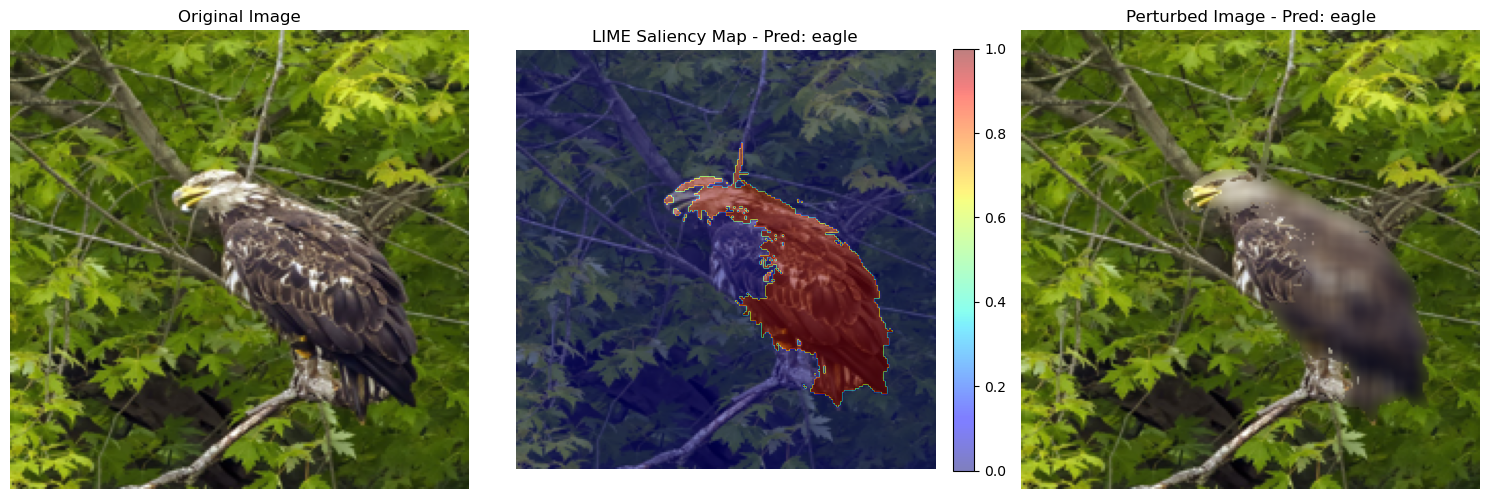

🔍 Đang chạy SHAP...


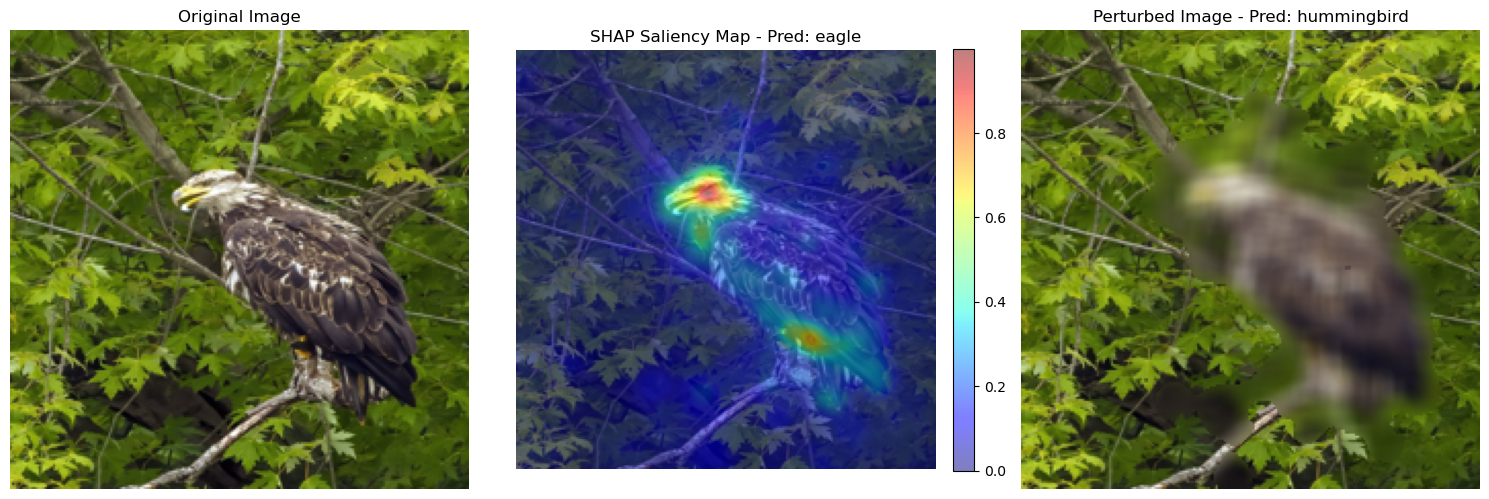

🔍 Đang chạy PEBEX...


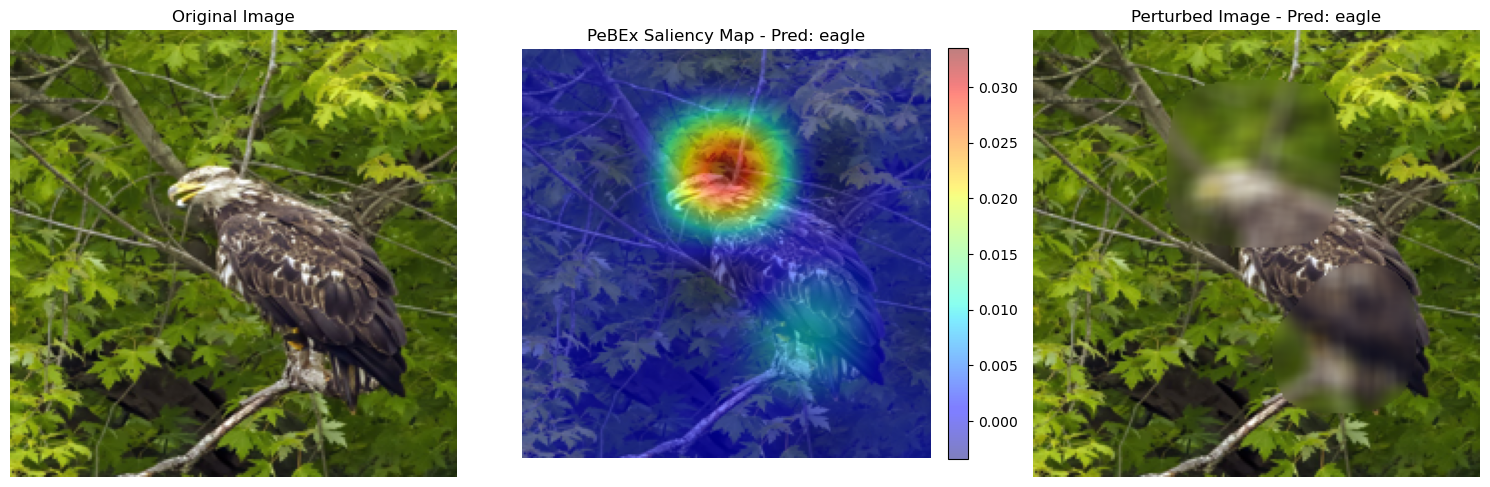

In [6]:
# LIME
lime_explanation, lime_mask = explain_with_lime(clf, img_np, clf.class_names, sample_output_dir, "caltech-101", org_image)
# SHAP
shap_values, shap_heatmap = explain_with_shap(clf, img_tensor, clf.class_names, sample_output_dir, "caltech-101", org_image)
# PEBEX
pebex_heatmap = explain_with_pebex(clf, img_tensor, clf.class_names, sample_output_dir, "caltech-101", org_image)

In [7]:
# clf = AnimalImageClassifier(data_dir=data_dir, output_dir=output_dir, img_size=img_size, args_model='resnet50')

# clf._build_dataloaders()
# clf.load_trained_model()

# # Dự đoán với mô hình
# print("\n🔮 Dự đoán với mô hình...")

# org_image = Image.open(img_path).convert('RGB').resize((img_size, img_size))
# transform = transforms.Compose([
#     transforms.Resize((img_size, img_size)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

# img_tensor = transform(org_image).unsqueeze(0)
# img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

# pred_class, confidence, probs = predict_with_model(clf.model, img_tensor)

# # Xác định index lớp đúng dựa trên tên class được chọn
# print(f"   - Predicted class: {clf.class_names[pred_class]} (index: {pred_class})")
# print(f"   - Confidence: {confidence:.4f}")

In [8]:
# # LIME
# lime_explanation, lime_mask = explain_with_lime(clf, img_np, clf.class_names, sample_output_dir, "animals", org_image)
# # SHAP
# shap_values, shap_heatmap = explain_with_shap(clf, img_tensor, clf.class_names, sample_output_dir, "animals", org_image)
# # PEBEX
# pebex_heatmap = explain_with_pebex(clf, img_tensor, clf.class_names, sample_output_dir, "animals", org_image)

In [9]:
from sample_prediction import AOPC_MoRF

lime_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/caltech-101/lime/LIME_mask.png')

lime_aopc_score = AOPC_MoRF(clf, lime_map_path, img_path)
lime_aopc_score

(224, 224, 3)
23


(23,
 [-0.002463698387145996,
  -0.004871368408203125,
  -0.0037341713905334473,
  0.0018993020057678223,
  0.009676814079284668,
  0.010645270347595215,
  0.01655137538909912,
  0.01606220006942749,
  0.010459959506988525,
  0.008859395980834961,
  0.01164853572845459,
  0.019679725170135498,
  0.02628326416015625,
  0.02014213800430298,
  0.025616466999053955,
  0.02531898021697998,
  0.029339313507080078,
  0.02774369716644287,
  0.028235018253326416,
  0.037323176860809326,
  0.029504120349884033,
  0.04393881559371948,
  0.05950963497161865,
  0.058386802673339844,
  0.06029397249221802,
  0.05883747339248657,
  0.053741455078125,
  0.09083008766174316,
  0.12859362363815308,
  0.12449949979782104,
  0.12368500232696533,
  0.11845511198043823,
  0.14891397953033447,
  0.16308355331420898,
  0.2156957983970642,
  0.20821893215179443,
  0.1831759214401245,
  0.1770920753479004,
  0.21394675970077515,
  0.2777155637741089,
  0.32470279932022095,
  0.33637863397598267,
  0.34055203199

In [10]:
from sample_prediction import AOPC_MoRF

shap_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/animals/shap/SHAP_mask.png')

shap_aopc_score = AOPC_MoRF(clf, shap_map_path, img_path)
shap_aopc_score

(224, 224, 3)
23


(23,
 [0.00019693374633789062,
  0.00035572052001953125,
  0.0024040937423706055,
  0.005631446838378906,
  0.004776597023010254,
  0.00527268648147583,
  0.006343185901641846,
  0.010484516620635986,
  0.0014376640319824219,
  0.002956390380859375,
  0.006480872631072998,
  0.005602359771728516,
  0.005819141864776611,
  0.003359556198120117,
  0.0100630521774292,
  0.016139328479766846,
  0.01994764804840088,
  0.024259328842163086,
  0.024296343326568604,
  0.023260772228240967,
  0.014483869075775146,
  0.012786567211151123,
  0.013477563858032227,
  0.016465961933135986,
  0.01748102903366089,
  0.011024415493011475,
  0.008343875408172607,
  0.01790100336074829,
  0.015991151332855225,
  0.01177757978439331,
  0.010303497314453125,
  0.011041522026062012,
  0.01761859655380249,
  0.028097689151763916,
  0.035333991050720215,
  0.03947502374649048,
  0.03888845443725586,
  0.09410500526428223,
  0.12691062688827515,
  0.1122707724571228,
  0.11717057228088379,
  0.1361778378486633

In [11]:
from sample_prediction import AOPC_MoRF

pebex_map_path = os.path.join(parent_dir, 'outputs/sample_explanation/animals/pebex/PeBEx_mask.png')

pebex_aopc_score = AOPC_MoRF(clf, pebex_map_path, img_path)
pebex_aopc_score

(224, 224, 3)
23


(23,
 [0.0009955763816833496,
  0.0039939284324646,
  0.006729722023010254,
  0.006626307964324951,
  0.015302836894989014,
  0.03189897537231445,
  0.0460127592086792,
  0.05838119983673096,
  0.04553985595703125,
  0.04993307590484619,
  0.06388098001480103,
  0.0661967396736145,
  0.07672208547592163,
  0.07879048585891724,
  0.09927487373352051,
  0.14018791913986206,
  0.1465442180633545,
  0.1485821008682251,
  0.1361333727836609,
  0.128229558467865,
  0.12417185306549072,
  0.1410733461380005,
  0.13282781839370728,
  0.16687071323394775,
  0.19381248950958252,
  0.20828598737716675,
  0.2240726351737976,
  0.25325441360473633,
  0.2948889136314392,
  0.3230627179145813,
  0.30555135011672974,
  0.29032206535339355,
  0.3305078148841858,
  0.3640308976173401,
  0.40438318252563477,
  0.43018728494644165,
  0.43101978302001953,
  0.45454734563827515,
  0.5128109455108643,
  0.5833381116390228,
  0.6030672788619995,
  0.620637059211731,
  0.5948328077793121,
  0.6085913181304932,

In [12]:
# len(aopc_score[1])

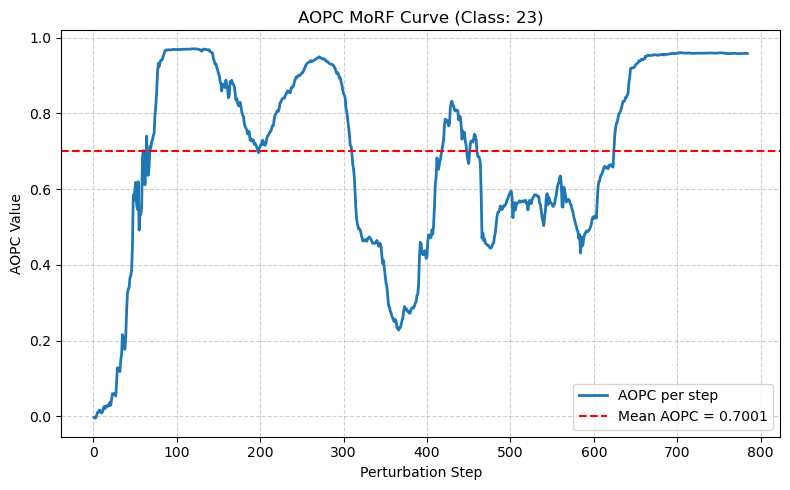

In [13]:
# Giải nén kết quả
class_origin, AOPC_list, mean_AOPC = lime_aopc_score
    
# Tạo trục x là số bước perturbation
steps = np.arange(1, len(AOPC_list) + 1)

# Vẽ biểu đồ đường
plt.figure(figsize=(8, 5))
plt.plot(steps, AOPC_list, linestyle='-', linewidth=2, label='AOPC per step')
plt.axhline(mean_AOPC, color='red', linestyle='--', linewidth=1.5, label=f'Mean AOPC = {mean_AOPC:.4f}')

# Thêm tiêu đề và nhãn
plt.title(f"AOPC MoRF Curve (Class: {class_origin.item() if hasattr(class_origin, 'item') else class_origin})")
plt.xlabel("Perturbation Step")
plt.ylabel("AOPC Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

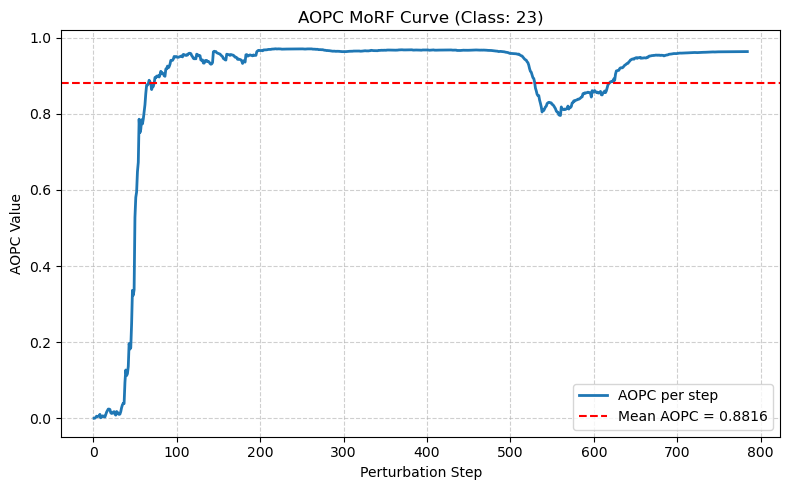

In [14]:
# Giải nén kết quả
class_origin, AOPC_list, mean_AOPC = shap_aopc_score

# Tạo trục x là số bước perturbation
steps = np.arange(1, len(AOPC_list) + 1)

# Vẽ biểu đồ đường
plt.figure(figsize=(8, 5))
plt.plot(steps, AOPC_list, linestyle='-', linewidth=2, label='AOPC per step')
plt.axhline(mean_AOPC, color='red', linestyle='--', linewidth=1.5, label=f'Mean AOPC = {mean_AOPC:.4f}')

# Thêm tiêu đề và nhãn
plt.title(f"AOPC MoRF Curve (Class: {class_origin.item() if hasattr(class_origin, 'item') else class_origin})")
plt.xlabel("Perturbation Step")

plt.ylabel("AOPC Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

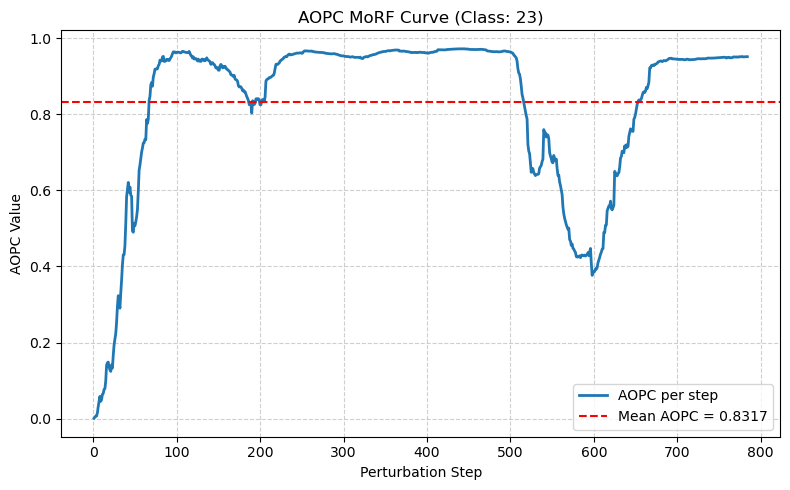

In [15]:
# Giải nén kết quả
class_origin, AOPC_list, mean_AOPC = pebex_aopc_score

# Tạo trục x là số bước perturbation
steps = np.arange(1, len(AOPC_list) + 1)

# Vẽ biểu đồ đường
plt.figure(figsize=(8, 5))
plt.plot(steps, AOPC_list, linestyle='-', linewidth=2, label='AOPC per step')
plt.axhline(mean_AOPC, color='red', linestyle='--', linewidth=1.5, label=f'Mean AOPC = {mean_AOPC:.4f}')

# Thêm tiêu đề và nhãn
plt.title(f"AOPC MoRF Curve (Class: {class_origin.item() if hasattr(class_origin, 'item') else class_origin})")
plt.xlabel("Perturbation Step")
plt.ylabel("AOPC Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Đếm tỷ lệ hình thay đổi class sau khi nhiễu

In [16]:
# from torchvision import transforms


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# imgs, _ = next(iter(clf.test_loader))
# imgs = imgs.to(device)

# samples = [
#     (img, label.item())
#     for imgs, labels in clf.test_loader
#     for img, label in zip(imgs, labels)
# ]

# flag_class_arr = []
# for idx, (img_t, label) in enumerate(samples):
#     # img_t: (C, H, W); convert for viz and batch for model
#     img_np = img_t.permute(1, 2, 0).cpu().numpy()
#     pred_class, confidence, probs = predict_with_model(clf.model, img_t.unsqueeze(0))
#     print(clf.class_names)
#     pebex_heatmap, pebex_class_flag = explain_with_pebex(
#         clf=clf,
#         img_tensor=img_t.unsqueeze(0),
#         class_names=clf.class_names,
#         output_dir=None,
#         args_dataset="caltech-101",
#         org_img=transforms.ToPILImage()(img_t).convert('RGB')
#     )

#     flag_class_arr.append(pebex_class_flag)



In [17]:
# flag_class_arr = np.array(flag_class_arr)
# len(flag_class_arr)
# ratio = np.mean(flag_class_arr)
# ratio

In [18]:
# flag_class_arr 

In [19]:
# from torchvision import transforms


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# imgs, _ = next(iter(clf.test_loader))
# imgs = imgs.to(device)

# samples = [
#     (img, label.item())
#     for imgs, labels in clf.test_loader
#     for img, label in zip(imgs, labels)
# ]

# flag_class_arr = []
# for idx, (img_t, label) in enumerate(samples):
#     # img_t: (C, H, W); convert for viz and batch for model
#     img_np = img_t.permute(1, 2, 0).cpu().numpy()
#     pred_class, confidence, probs = predict_with_model(clf.model, img_t.unsqueeze(0))
#     print(clf.class_names)
#     lime_heatmap, lime_mask, lime_class_flag = explain_with_lime(
#         clf=clf,
#         img_np=img_np,
#         class_names=clf.class_names,
#         output_dir=None,
#         args_dataset="caltech-101",
#         org_img=transforms.ToPILImage()(img_t).convert('RGB')
#     )

#     flag_class_arr.append(lime_class_flag)

In [20]:
# flag_class_arr = np.array(flag_class_arr)
# len(flag_class_arr)
# ratio = np.mean(flag_class_arr)
# ratio